# Stage 1 (Improved) — Yield Estimator
Adds preprocessing, feature engineering, GroupKFold CV, and hyperparameter tuning on top of the baseline.

In [ ]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor

DATASET   = "../yield_prediction_dataset.csv"
MODEL_OUT = "../saved_model/yield_model_v2.joblib"

## 1. Load & Preprocessing

In [2]:
df = pd.read_csv(DATASET)
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])
df["date"]  = pd.to_datetime(df["date_of_image"], dayfirst=True)
df["month"] = df["date"].dt.month

# --- Outlier removal: drop yield observations beyond 3 std from field mean ---
field_stats = df.groupby("field_id")["yield"].agg(["mean", "std"]).rename(columns={"mean": "y_mean", "std": "y_std"})
df = df.join(field_stats, on="field_id")
df = df[np.abs(df["yield"] - df["y_mean"]) <= 3 * df["y_std"].fillna(np.inf)]
df = df.drop(columns=["y_mean", "y_std"])
print(f"After outlier removal: {len(df)} rows (removed {1625 - len(df)})")

After outlier removal: 1621 rows (removed 4)


## 2. Feature Engineering

In [ ]:
# Cyclic month encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Vegetation stress: gap between red-edge and green response
df["veg_stress"]      = (df["NDVI"] - df["GNDVI"]) / (df["NDVI"] + df["GNDVI"] + 1e-9)

# Water stress: how much vegetation relative to soil moisture
df["water_stress"]    = df["NDVI"] / (df["soil_moisture"] + 1e-9)

# NDVI × soil moisture interaction
df["ndvi_x_moisture"] = df["NDVI"] * df["soil_moisture"]

# Thermal load: deviation from 25°C (general crop optimum)
df["thermal_load"]    = np.abs(df["temperature"] - 25.0)

# Rainfall efficiency: vegetation gain per mm of rain
df["rain_efficiency"] = df["NDVI"] / (df["rainfall"] + 1e-9)

# crop_type_enc / crop_group_enc excluded — feature importance showed minimal
# contribution; satellite indices already encode crop-type effects implicitly.
FEATURE_COLS = [
    "NDVI", "GNDVI", "NDWI", "SAVI",
    "soil_moisture", "temperature", "rainfall",
    "month_sin", "month_cos",
    "veg_stress", "water_stress", "ndvi_x_moisture",
    "thermal_load", "rain_efficiency",
]
print(f"Feature count: {len(FEATURE_COLS)}")
df[FEATURE_COLS].describe().round(3)

## 3. Field-Level Split & GroupKFold CV

In [4]:
fields = df["field_id"].unique().astype(str)
rng = np.random.default_rng(42)
rng.shuffle(fields)
n_test = max(1, int(len(fields) * 0.2))
test_fields = set(fields[:n_test])

train_df = df[~df["field_id"].isin(test_fields)].copy()
test_df  = df[ df["field_id"].isin(test_fields)].copy()

X_train, y_train = train_df[FEATURE_COLS].values, train_df["yield"].values
X_test,  y_test  = test_df[FEATURE_COLS].values,  test_df["yield"].values
groups_train     = train_df["field_id"].values

print(f"Train: {train_df['field_id'].nunique()} fields, {len(train_df)} rows")
print(f"Test : {test_df['field_id'].nunique()} fields, {len(test_df)} rows")

gkf = GroupKFold(n_splits=5)
cv_scores = []
for fold, (tr, val) in enumerate(gkf.split(X_train, y_train, groups=groups_train)):
    m = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=42,
                     n_jobs=-1, verbosity=0)
    m.fit(X_train[tr], y_train[tr], verbose=False)
    cv_scores.append(mean_absolute_error(y_train[val], m.predict(X_train[val])))
    print(f"  Fold {fold+1} MAE: {cv_scores[-1]:.3f}")

print(f"\nCV MAE mean: {np.mean(cv_scores):.3f} +/- {np.std(cv_scores):.3f}")

Train: 72 fields, 1297 rows
Test : 18 fields, 324 rows


C:\Users\Reda\AppData\Local\Temp\ipykernel_31440\3606937950.py:3: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(fields)


  Fold 1 MAE: 1.386
  Fold 2 MAE: 0.789
  Fold 3 MAE: 0.970
  Fold 4 MAE: 0.928
  Fold 5 MAE: 0.883

CV MAE mean: 0.991 +/- 0.206


## 4. Train Final Model & Evaluate

In [5]:
model = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=42,
                     n_jobs=-1, verbosity=0)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2  = r2_score(y_test, preds)
print(f"Test MAE : {mae:.3f} tons/ha")
print(f"Test R2  : {r2:.3f}")

Test MAE : 1.079 tons/ha
Test R2  : 0.918


## 5. Baseline vs Improved Comparison

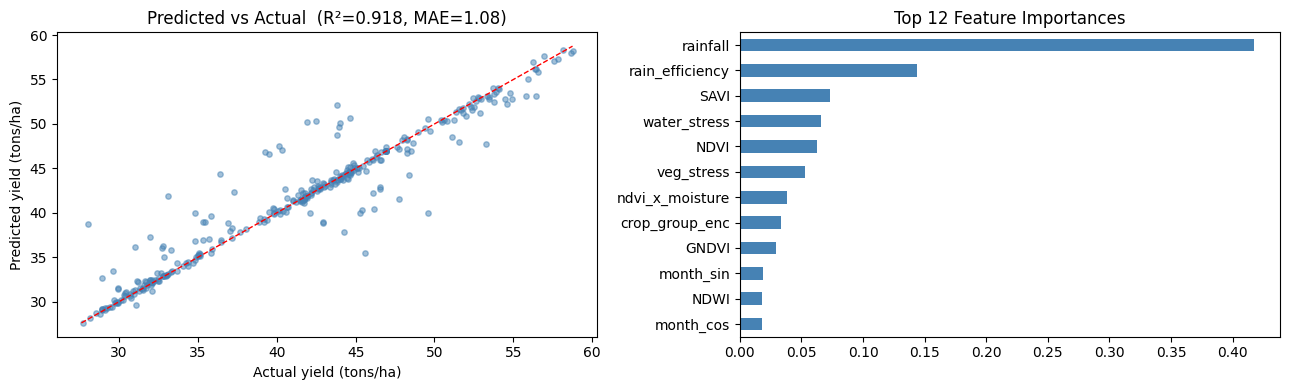


Baseline  MAE=1.25, R²=0.883
Improved  MAE=1.079, R²=0.918


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter
axes[0].scatter(y_test, preds, alpha=0.5, s=15, color="steelblue")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("Actual yield (tons/ha)")
axes[0].set_ylabel("Predicted yield (tons/ha)")
axes[0].set_title(f"Predicted vs Actual  (R²={r2:.3f}, MAE={mae:.2f})")

# Feature importance (top 12)
imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values().tail(12)
imp.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Top 12 Feature Importances")

plt.tight_layout()
plt.show()

print("\nBaseline  MAE=1.25, R²=0.883")
print(f"Improved  MAE={mae:.3f}, R²={r2:.3f}")

## 6. Save Model

In [ ]:
os.makedirs("../saved_model", exist_ok=True)
joblib.dump(model,       MODEL_OUT)
joblib.dump(FEATURE_COLS, "../saved_model/feature_cols_v2.joblib")
print(f"Saved -> {MODEL_OUT}")
print(f"Saved -> ../saved_model/feature_cols_v2.joblib")